In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import seaborn as sns
import h5py
from collections import Counter
import scipy.sparse as sp
from matplotlib.patches import Patch
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.patheffects as path_effects
from matplotlib_venn import venn3
import pyranges as pr
import yaml
import time
from itertools import combinations
import gget

import anndata as an
import scanpy as sc
import rapids_singlecell as rsc

import scvi
from scvi.external import SysVI

import cupy as cp
import cudf
import rmm
from rmm.allocators.cupy import rmm_cupy_allocator

from cuml.manifold.umap import simplicial_set_embedding
from scanpy.tools._utils import get_init_pos_from_paga 
from cuml.manifold.umap import find_ab_params

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

sc.settings.verbosity = 3

/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/nfs/turbo/umms-indikar/Cooper/conda_envs/rapids/lib/python3.12/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


# DEGS

In [2]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/three_libraries.h5ad"
gdata = sc.read_h5ad(fpath)
gdata

CPU times: user 1.43 s, sys: 2.98 s, total: 4.41 s
Wall time: 12.5 s


AnnData object with n_obs × n_vars = 21062 × 25739
    obs: 'dataset', 'source', 'cluster', 'group', 'label', 'S_score', 'G2M_score', 'phase', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mito', 'log1p_total_counts_mito', 'pct_counts_mito', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'filter_pass', 'bm_clusters', 'subgroup'
    var: 'gene_ids', 'feature_types', 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mito', 'filter_pass'
    uns: 'deg', 'rank_genes_groups', 'scvi_expression', 'subgroup_colors'
    obsm: 'X_paga', 'X_pca', 'X_pca_harmony', 'X_scvi

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:21)


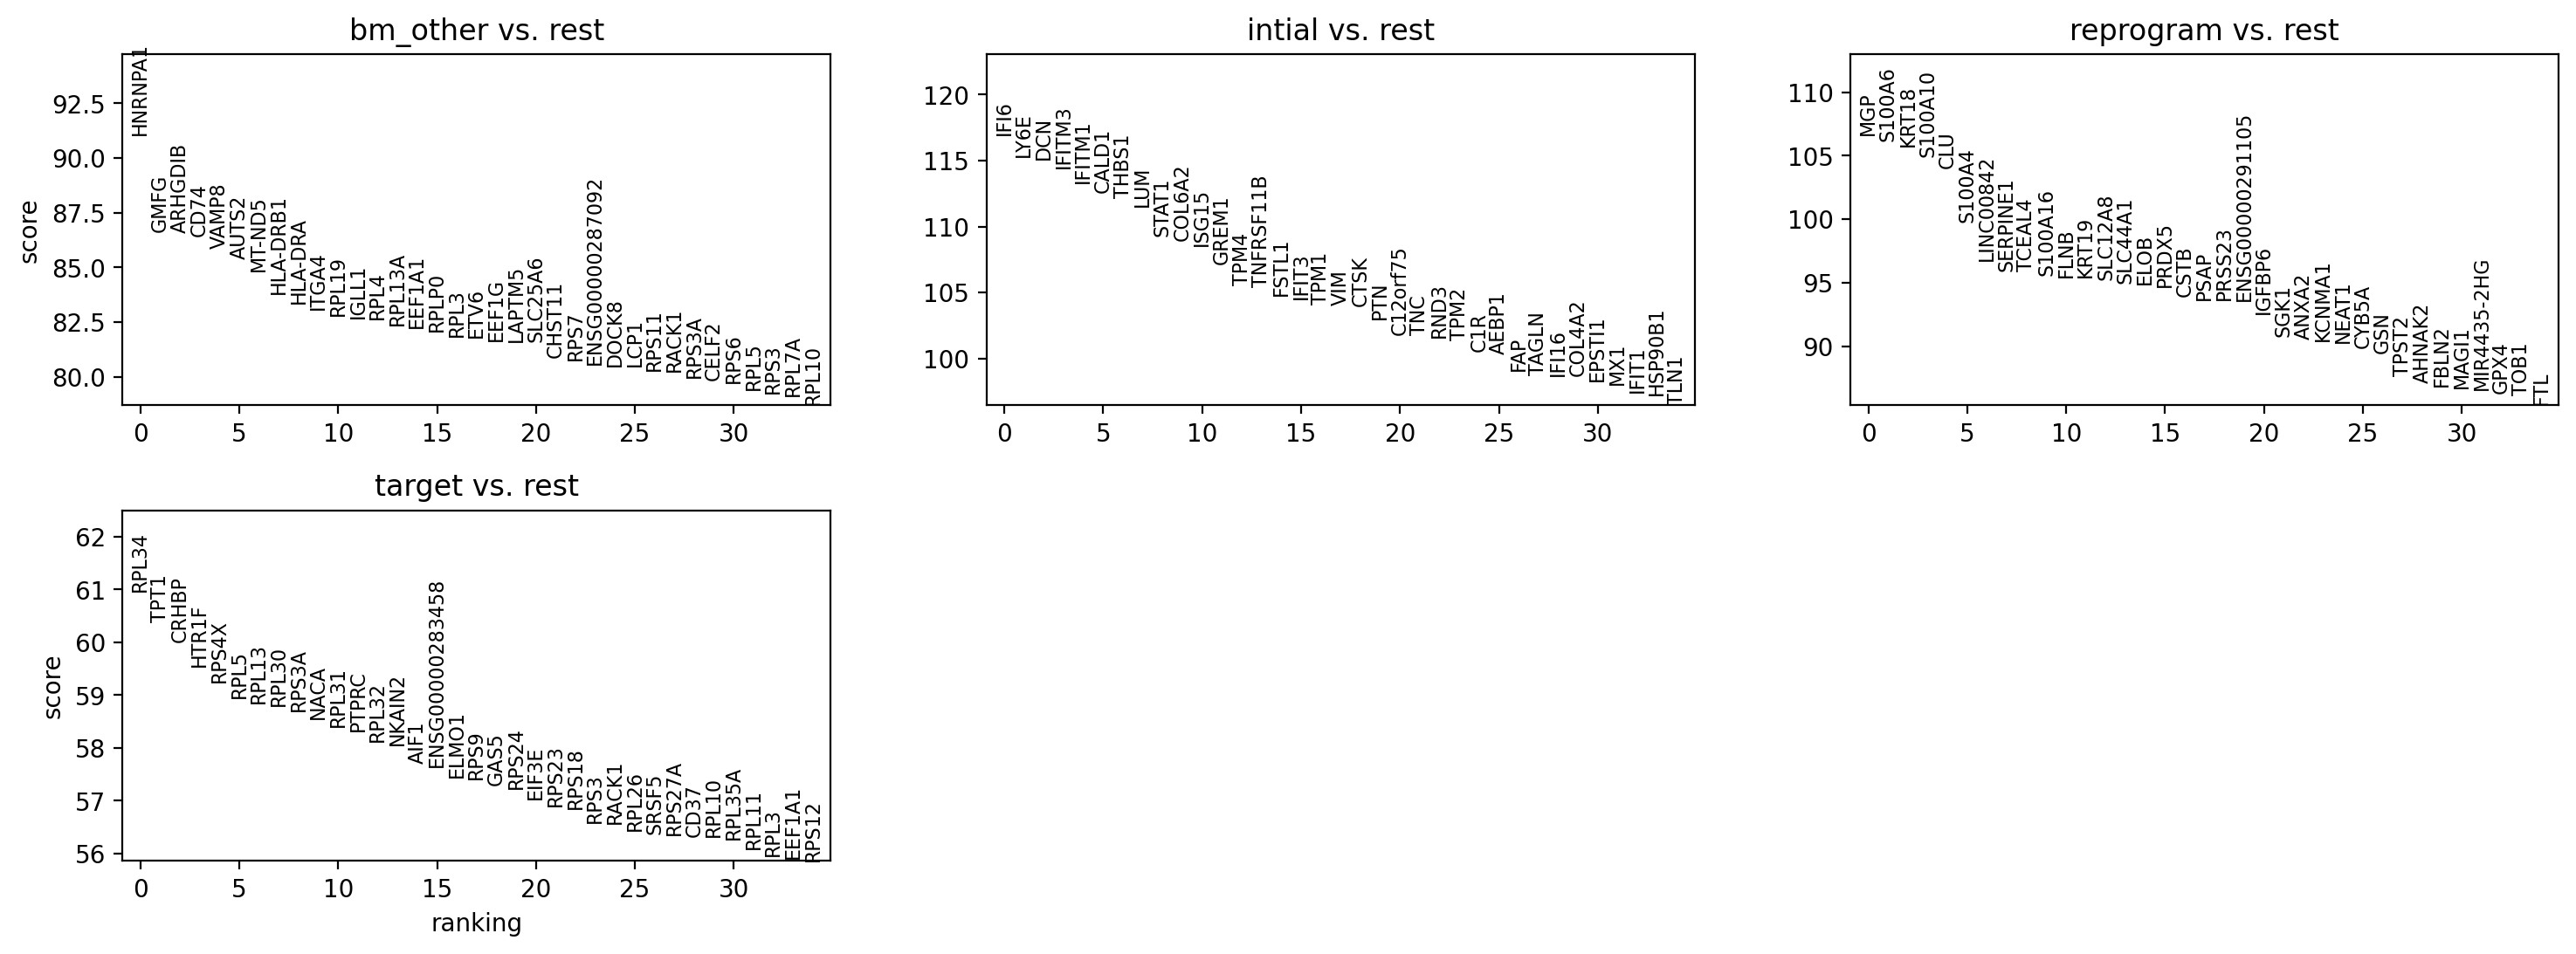

gene_deg.shape=(102956, 8)
gene_deg['names'].nunique()=25739
CPU times: user 41.5 s, sys: 26.1 s, total: 1min 7s
Wall time: 22.4 s


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference
0,bm_other,HNRNPA1,91.029953,3.361235,0.0,0.0,0.995445,0.795967
1,bm_other,GMFG,86.607552,4.679680,0.0,0.0,0.975709,0.100000
2,bm_other,ARHGDIB,86.570053,4.925317,0.0,0.0,0.983047,0.113968
3,bm_other,CD74,86.416565,5.466702,0.0,0.0,0.985577,0.094915
4,bm_other,VAMP8,85.869972,4.702915,0.0,0.0,0.940536,0.109410


In [3]:
%%time
rsc.get.anndata_to_CPU(gdata)
sc.tl.rank_genes_groups(
    gdata, 
    groupby='group',
    method='wilcoxon',
    use_raw=False,
    pts=True,
)

gene_deg = sc.get.rank_genes_groups_df(
    gdata, 
    group=None,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 3
sc.pl.rank_genes_groups(
    gdata,
    n_genes=35,
    sharey=False,
    ncols=3,
)

print(f"{gene_deg.shape=}")
print(f"{gene_deg['names'].nunique()=}")
gene_deg.head()

# ISOFORMS

In [4]:
%%time
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/isoforms.h5ad"
adata = sc.read_h5ad(fpath)

# map the t type to a nicer label
biotype_map = {
    'protein_coding':                   'PC',
    'retained_intron':                  'RI',
    'nonsense_mediated_decay':          'NMD',
    'protein_coding_CDS_not_defined':   'PC_no_CDS',
    'lncRNA':                           'lncRNA',
    'non_stop_decay':                   'NSD',
    'protein_coding_LoF':               'PC_LoF',
    'IG_C_gene':                        'IG_C',
    'IG_V_gene':                        'IG_V',
    'TR_J_gene':                        'TR_J',
    'TR_V_gene':                        'TR_V',
    'TR_C_gene':                        'TR_C',
    'IG_J_gene':                        'IG_J',
    'TR_V_pseudogene':                  'TR_V_pseudo',
    'IG_V_pseudogene':                  'IG_V_pseudo',
    'IG_C_pseudogene':                  'IG_C_pseudo',
    'TEC':                              'TEC',
}

adata.var['type_label'] = adata.var['transcript_type'].map(biotype_map)
print(adata.var['type_label'].value_counts().to_string())

adata

type_label
PC             51855
lncRNA         23570
RI             17612
PC_no_CDS      11407
NMD             8548
IG_V              71
NSD               60
TR_V              53
TEC               52
IG_V_pseudo       39
PC_LoF            23
TR_V_pseudo       17
TR_J               9
IG_C               8
TR_C               6
IG_C_pseudo        2
IG_J               1
CPU times: user 268 ms, sys: 427 ms, total: 695 ms
Wall time: 1.67 s


AnnData object with n_obs × n_vars = 21062 × 113335
    obs: 'dataset', 'dataset_bdata', 'source', 'cluster', 'group', 'label', 'filter_pass', 'bm_clusters', 'subgroup'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'type_label'
    uns: 'subgroup_colors'
    obsm: 'X_umap'

In [5]:
%%time 
# === Load and filter GTF ===
gtf_file = "/nfs/turbo/umms-indikar/shared/projects/reference_genome/prebuilt/refdata-gex-GRCh38-2024-A/genes/genes.gtf"
gtf = pr.read_gtf(gtf_file)

exons = gtf[gtf.Feature == "exon"].df
print(f"{exons.shape=}")
exons.head()


exons.shape=(1586950, 27)
CPU times: user 51.4 s, sys: 4.09 s, total: 55.5 s
Wall time: 55.6 s


,Chromosome,Source,Feature,Start,End,Score,Strand,Frame,gene_id,gene_version,...,transcript_name,transcript_support_level,havana_transcript,exon_number,exon_id,exon_version,hgnc_id,havana_gene,protein_id,ccdsid
0,GL000009.2,ENSEMBL,exon,56139,58376,.,-,.,ENSG00000278704,1,...,ENST00000618686,NA,NaN,1,ENSE00003753029,1,NaN,NaN,ENSP00000484918.1,NaN
1,GL000194.1,ENSEMBL,exon,114985,115018,.,-,.,ENSG00000277400,1,...,ENST00000613230,1,NaN,1,ENSE00002299440,2,NaN,NaN,ENSP00000483280.1,NaN
2,GL000194.1,ENSEMBL,exon,112791,112850,.,-,.,ENSG00000277400,1,...,ENST00000613230,1,NaN,2,ENSE00003739295,1,NaN,NaN,ENSP00000483280.1,NaN
3,GL000194.1,ENSEMBL,exon,53589,55676,.,-,.,ENSG00000277400,1,...,ENST00000613230,1,NaN,3,ENSE00003723764,1,NaN,NaN,ENSP00000483280.1,NaN
4,GL000194.1,ENSEMBL,exon,114985,115055,.,-,.,ENSG00000274847,1,...,MAFIP-201,1,NaN,1,ENSE00003736481,1,HGNC:31102,NaN,ENSP00000478910.1,NaN


In [6]:
fpath = "../../resources/isoform_map.csv.gz"

idf = pd.read_csv(fpath)
print(f"{idf.shape=}")
idf['uniprot'] = np.where(idf['UniProtKB/TrEMBL ID'].isna(), idf['UniProtKB/Swiss-Prot ID'], idf['UniProtKB/TrEMBL ID'])
transcript_2_uniprot = dict(zip(idf['Transcript name'].values, idf['uniprot'].values))

adata.var['uniprot'] = adata.var.index.map(transcript_2_uniprot)
adata.var['uniprot'].nunique()


idf.shape=(110149, 11)


38983

In [7]:
%%time
fpath = "../../resources/AS_events.csv.gz"

# Read and filter
asdf = pd.read_csv(fpath)
asdf = asdf[asdf['transcript_name'].notna()]
print(f"{asdf.shape=}")

asdf.head()

asdf.shape=(63700, 12)
CPU times: user 92.3 ms, sys: 203 μs, total: 92.5 ms
Wall time: 93 ms


,gene_name,gene_id,transcript_name,transcript_id,A3,A5,AF,AL,MX,RI,SE,num_events
0,A2M,ENSG00000175899,A2M-201,ENST00000318602,False,False,False,False,False,False,True,1
1,A2M,ENSG00000175899,A2M-202,ENST00000404455,False,False,False,False,False,False,True,1
2,A2ML1,ENSG00000166535,A2ML1-202,ENST00000536789,False,True,False,False,False,False,False,1
3,A2ML1,ENSG00000166535,A2ML1-205,ENST00000539547,False,False,True,False,False,False,False,1
4,A2ML1,ENSG00000166535,A2ML1-207,ENST00000541459,False,False,True,True,False,False,False,2


In [8]:
fpath = "../../resources/allTFs_hg38.txt"
tf_list = [x.strip() for x in open(fpath)]
tf_list[:10]

['ZNF354C',
 'KLF12',
 'ZNF143',
 'ZIC2',
 'ZNF274',
 'SP2',
 'ZBTB7A',
 'BCL6B',
 'ZBTB49',
 'ZIC1']

In [9]:
rsc.get.anndata_to_GPU(adata)
rsc.pp.filter_genes(adata, min_counts=30)

adata.layers['counts'] = adata.X.copy()

rsc.pp.normalize_total(adata, target_sum=1e4)
rsc.pp.log1p(adata)

adata.layers['log_norm'] = adata.X.copy()
adata

filtered out 43826 genes that are detected in less than 30 counts


AnnData object with n_obs × n_vars = 21062 × 69509
    obs: 'dataset', 'dataset_bdata', 'source', 'cluster', 'group', 'label', 'filter_pass', 'bm_clusters', 'subgroup'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'type_label', 'uniprot', 'n_counts', 'n_cells'
    uns: 'subgroup_colors', 'log1p'
    obsm: 'X_umap'
    layers: 'counts', 'log_norm'

ranking genes
    finished: added to `.uns['rank_genes_groups']`
    'names', sorted np.recarray to be indexed by group ids
    'scores', sorted np.recarray to be indexed by group ids
    'logfoldchanges', sorted np.recarray to be indexed by group ids
    'pvals', sorted np.recarray to be indexed by group ids
    'pvals_adj', sorted np.recarray to be indexed by group ids (0:00:33)


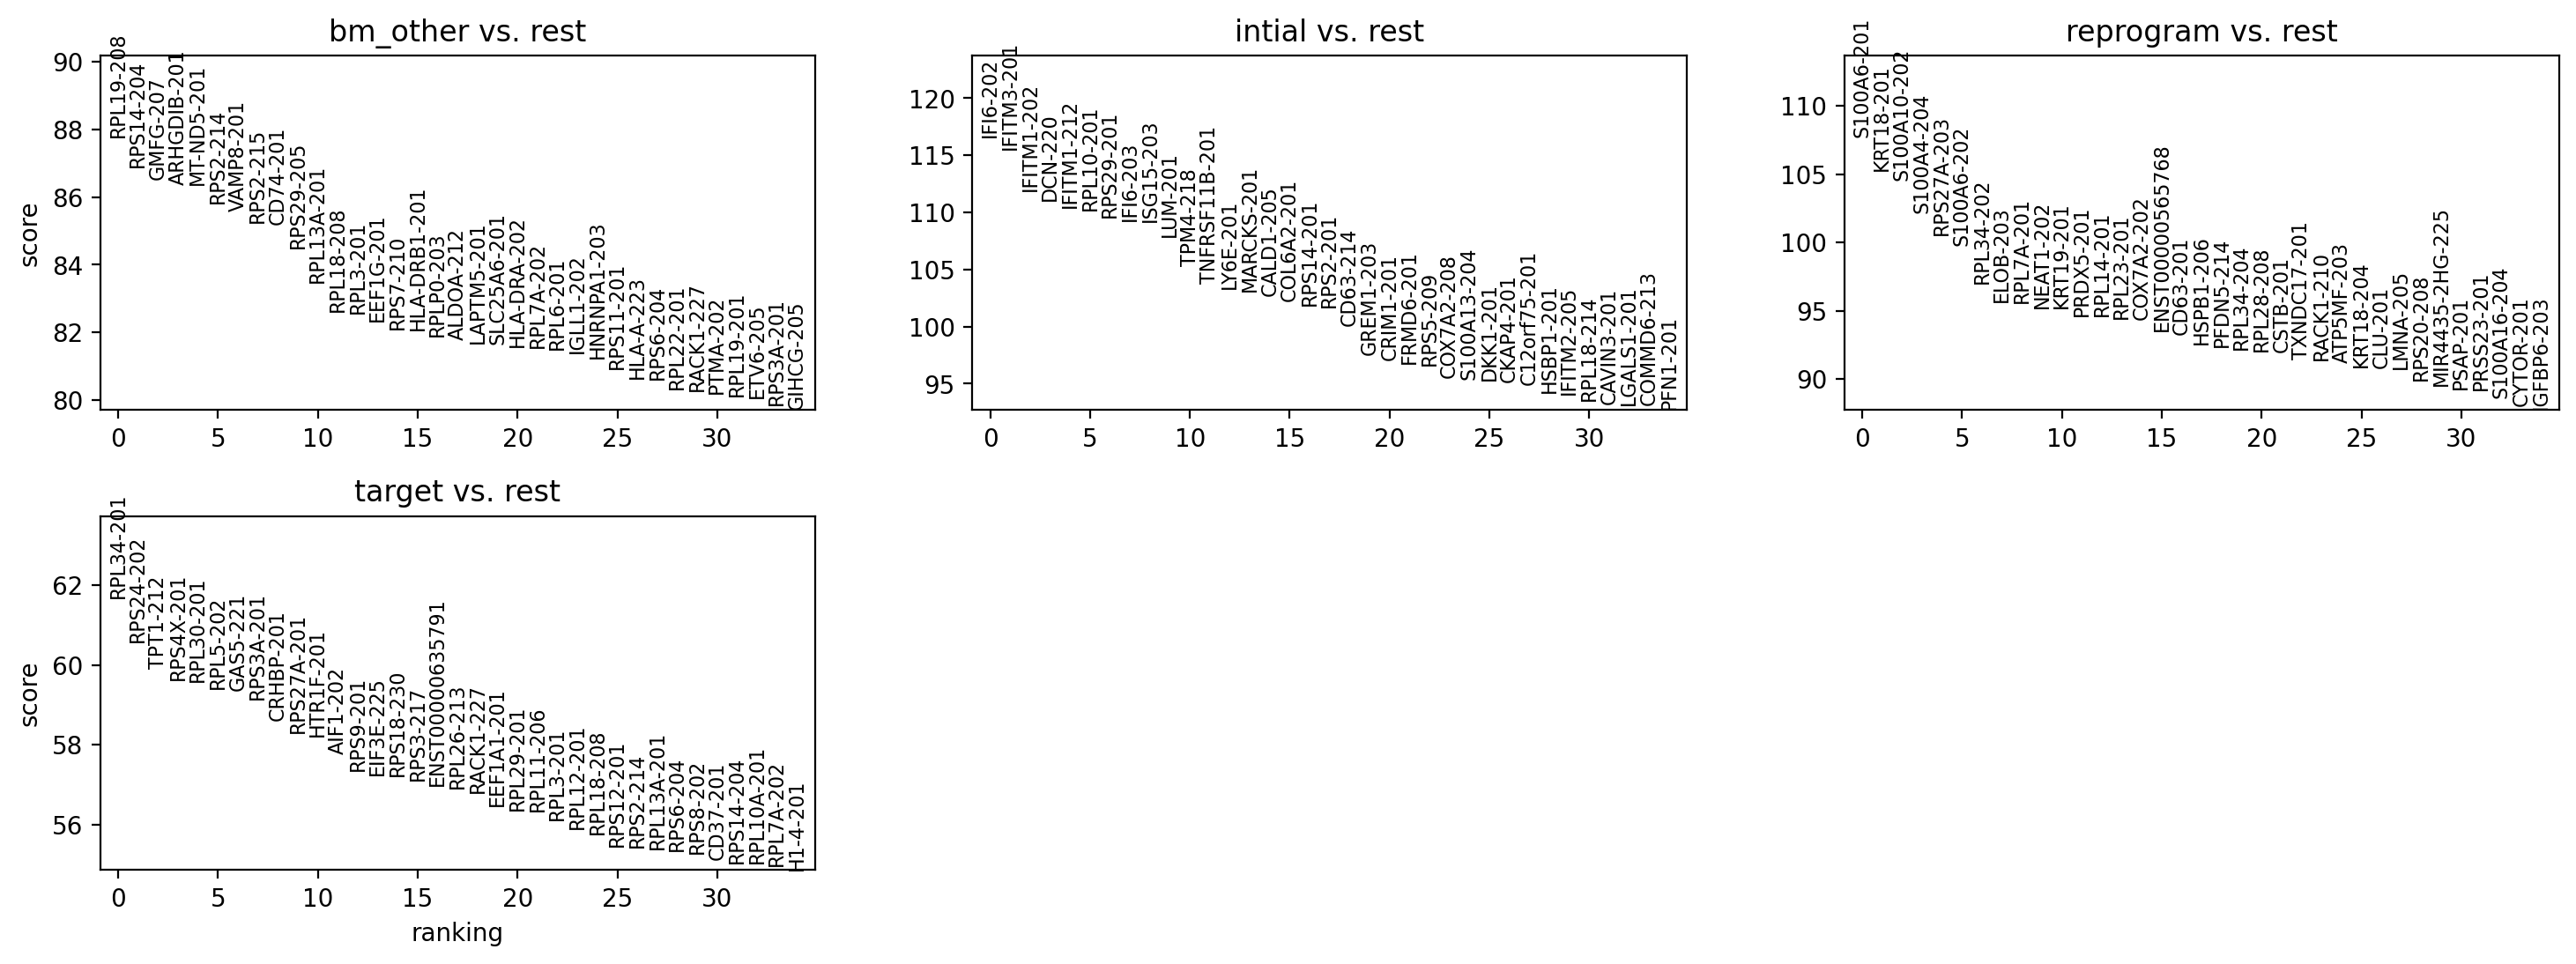

CPU times: user 1min 25s, sys: 1min 1s, total: 2min 26s
Wall time: 34.4 s


,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,transcript_name
0,bm_other,RPL19,87.760811,5.114663,0.0,0.0,0.983300,0.159790,RPL19-208
1,bm_other,RPS14,86.878601,7.402966,0.0,0.0,0.995445,0.094857,RPS14-204
2,bm_other,GMFG,86.528618,5.072167,0.0,0.0,0.973178,0.087025,GMFG-207
3,bm_other,ARHGDIB,86.367561,5.231786,0.0,0.0,0.976468,0.106838,ARHGDIB-201
4,bm_other,MT,86.367462,2.583083,0.0,0.0,0.999241,0.848627,MT-ND5-201


In [10]:
%%time
rsc.get.anndata_to_CPU(adata)
sc.tl.rank_genes_groups(
    adata, 
    groupby='group',
    method='wilcoxon',
    use_raw=False,
    pts=True,
)

transcript_deg = sc.get.rank_genes_groups_df(
    adata, 
    group=None,
    pval_cutoff=0.05,
    log2fc_min=1.0,
    log2fc_max=10.0,
)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 6, 3
sc.pl.rank_genes_groups(
    adata,
    n_genes=35,
    sharey=False,
    ncols=3,
)

transcript_deg['transcript_name'] = transcript_deg['names']
transcript_deg['names'] = transcript_deg['names'].str.split('-').str[0]

transcript_deg.head()

# Simple Filters

In [11]:
# parameters
pct_group_quantile = 0.70    # top 10% by pct_nz_group
pct_ref_quantile   = 0.5    # bottom 10% by pct_nz_reference
top_n_genes        = 50

# 1. compute per‑group thresholds
thresholds = transcript_deg.groupby('group').agg(
    group_threshold=('pct_nz_group',   lambda x: x.quantile(pct_group_quantile)),
    reference_threshold=('pct_nz_reference', lambda x: x.quantile(pct_ref_quantile))
)

# 2. merge thresholds back into deg
deg2 = transcript_deg.merge(thresholds, on='group')

# 3. filter by percentile criteria
deg_filtered = deg2[
    (deg2['pct_nz_group']     >= deg2['group_threshold']) &
    (deg2['pct_nz_reference'] <= deg2['reference_threshold'])
]

# 4. sort within each group: log‐FC ↓, pct_nz_group ↓, pct_nz_reference ↑
deg_sorted = deg_filtered.sort_values(
    by=['group','logfoldchanges','pct_nz_group','pct_nz_reference'],
    ascending=[True, False, False, True],
)

# 5. take top N per group
top_genes = deg_sorted.groupby('group').head(top_n_genes)

# # 6. keep gene names and metrics
result = top_genes[['group','names', 'transcript_name', 'logfoldchanges','pct_nz_group','pct_nz_reference']]

print(result.to_string(index=False))

    group           names transcript_name  logfoldchanges  pct_nz_group  pct_nz_reference
 bm_other          VPREB3      VPREB3-201        9.767947      0.141700          0.000935
 bm_other          RNASE2      RNASE2-201        9.696671      0.288968          0.000994
 bm_other          VPREB1      VPREB1-202        9.429795      0.407389          0.002396
 bm_other        RNASE2CP    RNASE2CP-203        9.273715      0.171053          0.000292
 bm_other           MS4A3       MS4A3-201        8.895479      0.135121          0.000468
 bm_other            CTSG        CTSG-201        8.755919      0.179656          0.000701
 bm_other           IGLL1       IGLL1-203        8.643304      0.176619          0.000526
 bm_other          SUCNR1      SUCNR1-201        8.610816      0.187753          0.000409
 bm_other            AZU1        AZU1-201        8.579807      0.169281          0.001929
 bm_other           IGLL1       IGLL1-201        8.085269      0.242915          0.000994
 bm_other 

In [12]:
def get_transcripts(query, adata=adata):
    df = adata.var[adata.var['gene_name'] == query].copy()
    columns = [
        'gene_name',
        'gene_type',
        'transcript_name',
        'transcript_type',
        'uniprot',
    ]
    df = df[columns]
    return df

get_transcripts("HLF")

,gene_name,gene_type,transcript_name,transcript_type,uniprot
transcript_name,,,,,
HLF-201,HLF,protein_coding,HLF-201,protein_coding,Q16534
HLF-204,HLF,protein_coding,HLF-204,protein_coding,I3L4R4
HLF-208,HLF,protein_coding,HLF-208,protein_coding,Q16534


In [13]:
adata

AnnData object with n_obs × n_vars = 21062 × 69509
    obs: 'dataset', 'dataset_bdata', 'source', 'cluster', 'group', 'label', 'filter_pass', 'bm_clusters', 'subgroup'
    var: 'gene_id', 'gene_name', 'gene_type', 'transcript_name', 'transcript_type', 'Chromosome', 'Start', 'End', 'transcript_id', 'type_label', 'uniprot', 'n_counts', 'n_cells'
    uns: 'subgroup_colors', 'log1p', 'rank_genes_groups'
    obsm: 'X_umap'
    layers: 'counts', 'log_norm'

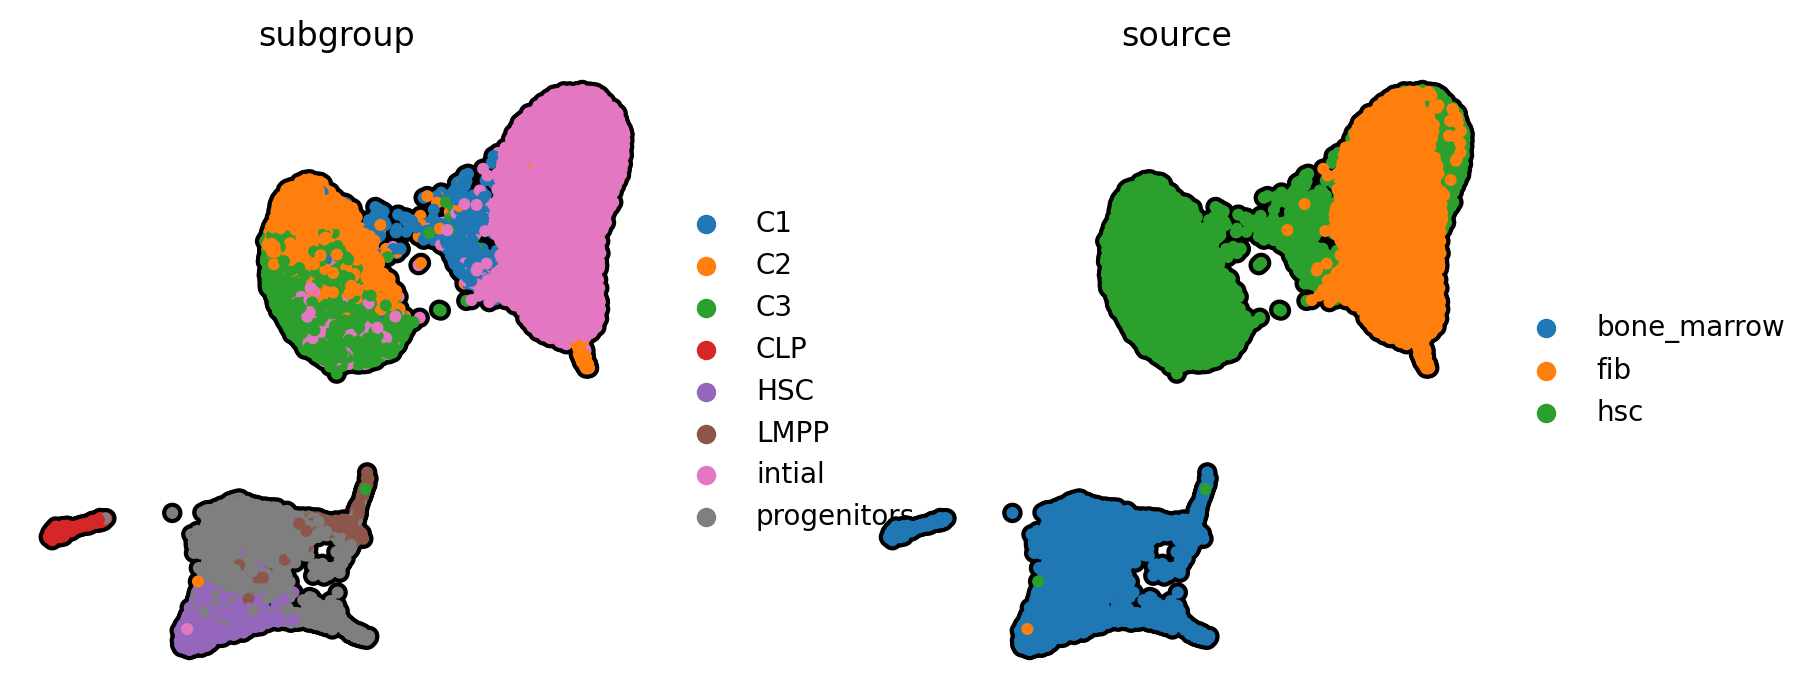

In [14]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata[adata.obs['filter_pass'], :].copy(),
    ncols=4,
    sort_order=True,
    color=['subgroup', 'source'],
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    cmap='magma',
    colorbar_loc=None,
    frameon=False,
)

gene_name      gene_type transcript_name transcript_type uniprot
     CD34 protein_coding        CD34-201  protein_coding  P28906
     CD34 protein_coding        CD34-202  protein_coding  P28906
     CD34 protein_coding        CD34-203  protein_coding  Q5JTA5


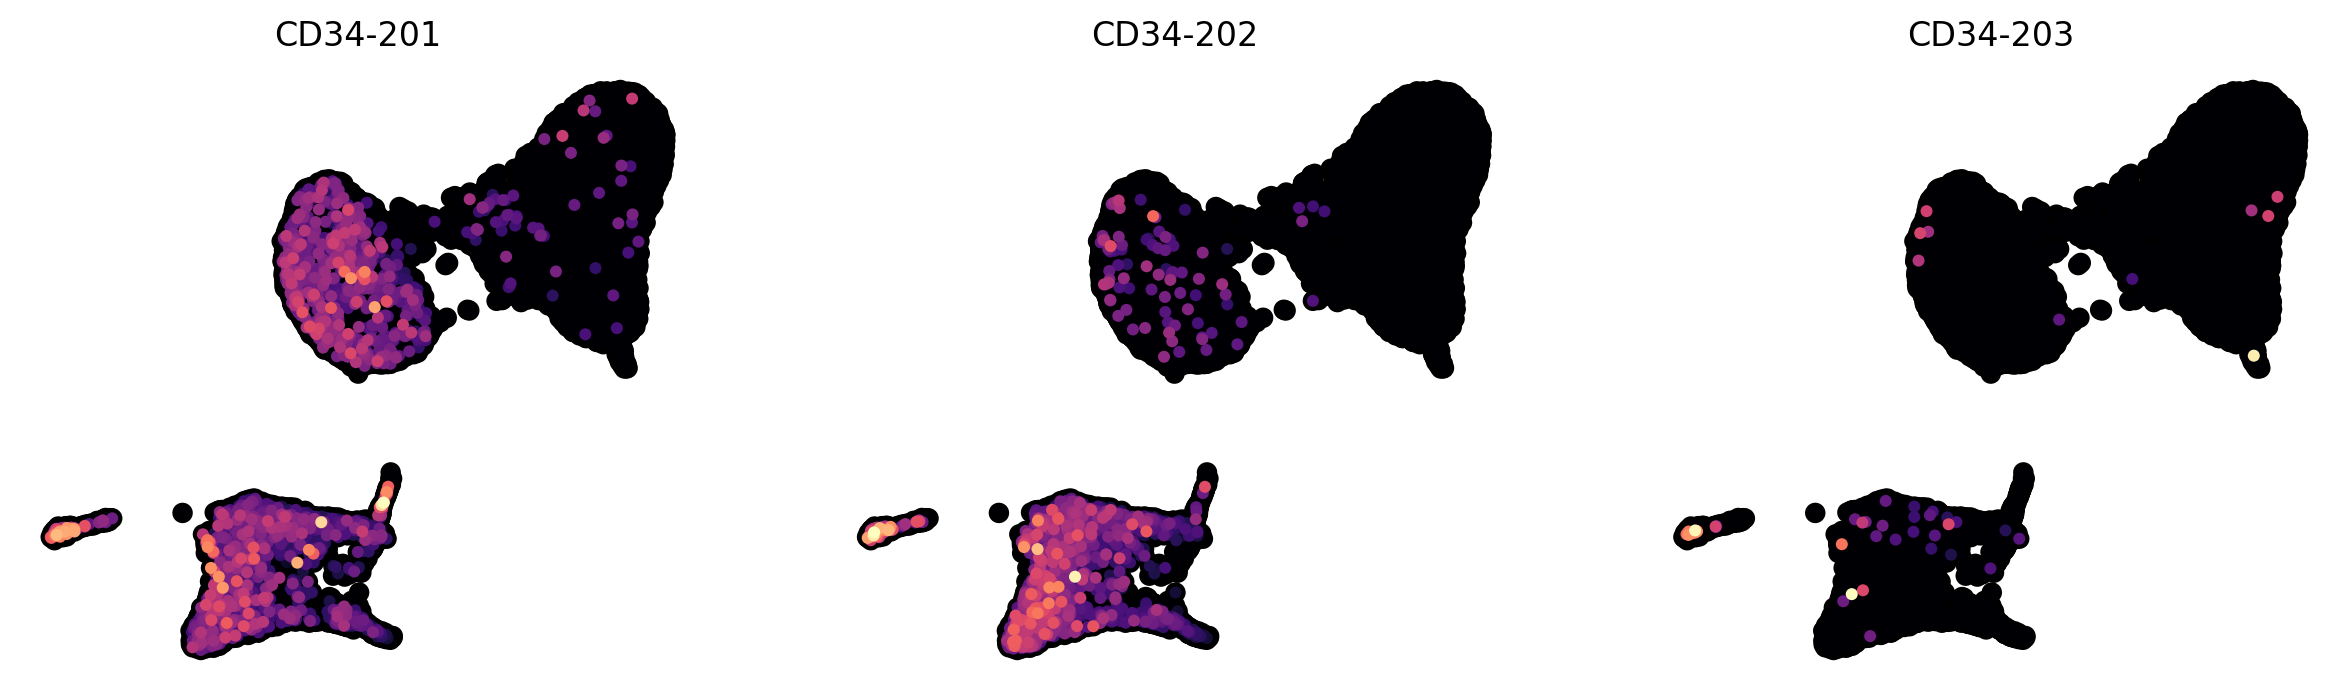

In [15]:
rsc.get.anndata_to_CPU(adata)

query = 'CD34'
label_df = get_transcripts(query)
print(label_df.to_string(index=False))

color = label_df.index.to_list()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata[adata.obs['filter_pass'], :].copy(),
    ncols=4,
    sort_order=True,
    color=color,
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    cmap='magma',
    colorbar_loc=None,
    frameon=False,
)

# transcription factors

In [16]:
# parameters
pct_group_quantile = 0.50    # top 10% by pct_nz_group
pct_ref_quantile   = 0.55    # bottom 10% by pct_nz_reference
top_n_genes        = 50

# 1. compute per‑group thresholds
thresholds = transcript_deg.groupby('group').agg(
    group_threshold=('pct_nz_group',   lambda x: x.quantile(pct_group_quantile)),
    reference_threshold=('pct_nz_reference', lambda x: x.quantile(pct_ref_quantile))
)

# 2. merge thresholds back into deg
deg2 = transcript_deg.merge(thresholds, on='group')

# 3. filter by percentile criteria
deg_filtered = deg2[
    (deg2['pct_nz_group']     >= deg2['group_threshold']) &
    (deg2['pct_nz_reference'] <= deg2['reference_threshold']) &
    (deg2['names'].isin(tf_list))
]

# 4. sort within each group: log‐FC ↓, pct_nz_group ↓, pct_nz_reference ↑
deg_sorted = deg_filtered.sort_values(
    by=['group','logfoldchanges','pct_nz_group','pct_nz_reference'],
    ascending=[True, False, False, True],
)

# 5. take top N per group
top_genes = deg_sorted.groupby('group').head(top_n_genes)
top_genes[top_genes['group'] == 'reprogram'].head(50)

,group,names,scores,logfoldchanges,pvals,pvals_adj,pct_nz_group,pct_nz_reference,transcript_name,group_threshold,reference_threshold
16944,reprogram,ZBTB16,7.516166,5.194997,5.640605e-14,6.666772e-13,0.066717,0.002207,ZBTB16-216,0.062452,0.017038
15822,reprogram,ZBTB16,19.592373,4.855908,1.796187e-85,7.085763e-84,0.175781,0.008002,ZBTB16-201,0.062452,0.017038
16604,reprogram,SOX13,9.348787,4.546619,8.865871e-21,1.331586e-19,0.083778,0.003449,SOX13-203,0.062452,0.017038
15669,reprogram,CD59,24.474581,4.165434,2.755476e-132,1.554630e-130,0.223610,0.013313,CD59-211,0.062452,0.017038
16273,reprogram,LARP4,11.858070,4.017274,1.954266e-32,3.928256e-31,0.108911,0.007105,LARP4-217,0.062452,0.017038
15759,reprogram,ZNF841,21.488508,3.819428,1.994192e-102,9.065684e-101,0.200305,0.015727,ZNF841-202,0.062452,0.017038
17027,reprogram,ZFHX3,7.176114,3.657322,7.172083e-13,8.055006e-12,0.067022,0.005380,ZFHX3-204,0.062452,0.017038
16341,reprogram,KDM4B,11.240232,3.647479,2.587016e-29,4.869236e-28,0.104950,0.008347,KDM4B-201,0.062452,0.017038
15960,reprogram,KDM4B,16.295597,3.543938,1.060627e-59,3.203961e-58,0.153237,0.013106,KDM4B-211,0.062452,0.017038
16619,reprogram,LARP4,9.245944,3.535499,2.331735e-20,3.451375e-19,0.086672,0.007174,LARP4-215,0.062452,0.017038


In [17]:
# [x for x in gene_deg['names'].unique() if 'TEAD' in x]

gene_name      gene_type transcript_name transcript_type uniprot
    TEAD4 protein_coding       TEAD4-202  protein_coding  Q53GI4
    TEAD4 protein_coding       TEAD4-203  protein_coding  Q15561
    TEAD4 protein_coding       TEAD4-207  protein_coding  H0YGS2


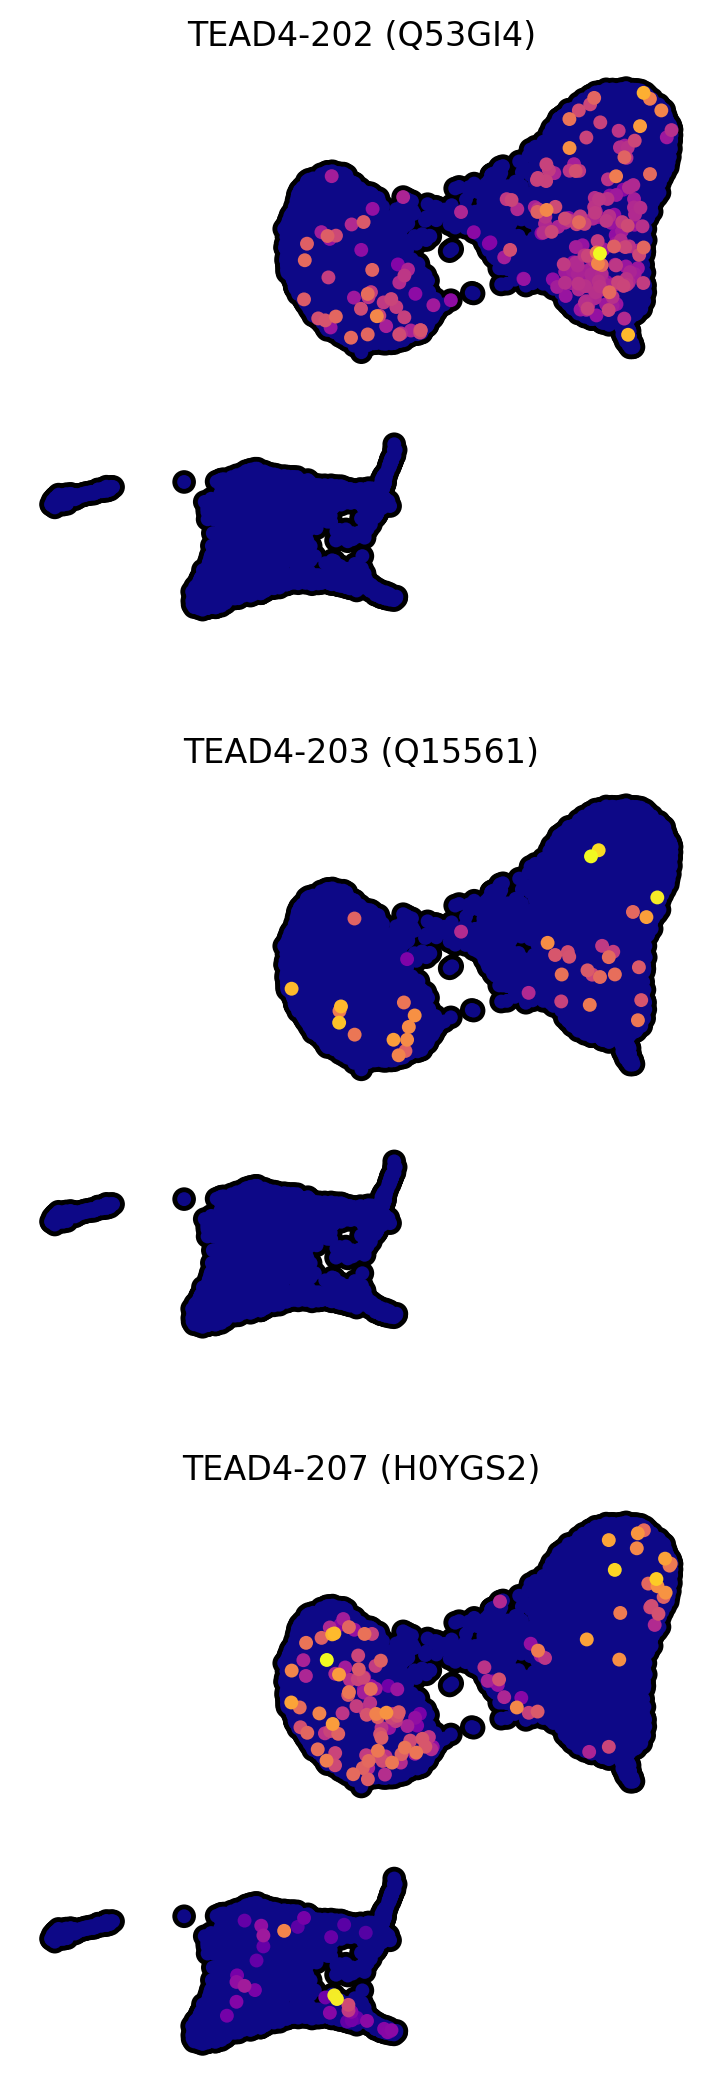

In [18]:
rsc.get.anndata_to_CPU(adata)

query = 'TEAD4'
# query = 'YAP1'
# query = 'YWHAZ'
# query = 'FOXD1'
label_df = get_transcripts(query)
print(label_df.to_string(index=False))

color = label_df.index.to_list()
titles = label_df[['transcript_name', 'uniprot']].apply(lambda x: f"{x[0]} ({x[1]})", axis=1)
titles = titles.to_list()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3.5, 4

sc.pl.umap(
    adata[adata.obs['filter_pass'], :].copy(),
    ncols=1,
    sort_order=True,
    color=color,
    size=100,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    title=titles,
    # cmap='magma',
    cmap='plasma',
    colorbar_loc=None,
    frameon=False,
)

gene_name      gene_type transcript_name transcript_type uniprot
    TEAD4 protein_coding       TEAD4-202  protein_coding  Q53GI4
    TEAD4 protein_coding       TEAD4-203  protein_coding  Q15561
    TEAD4 protein_coding       TEAD4-207  protein_coding  H0YGS2


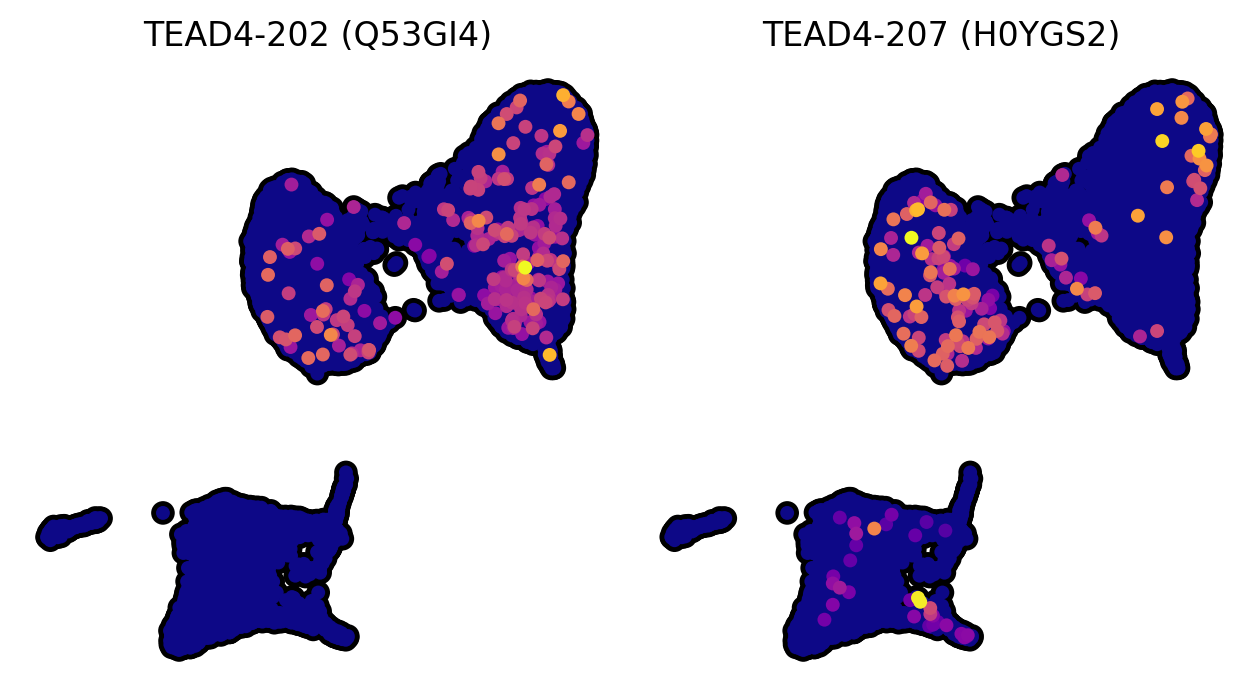

In [19]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3.65, 4

print(label_df.to_string(index=False))

sc.pl.umap(
    adata[adata.obs['filter_pass'], :].copy(),
    ncols=2,
    sort_order=True,
    color=['TEAD4-202', 'TEAD4-207'],
    size=100,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    wspace=.05,
    title=['TEAD4-202 (Q53GI4)', 'TEAD4-207 (H0YGS2)'],
    # cmap='magma',
    cmap='plasma',
    colorbar_loc=None,
    frameon=False,
)

In [20]:
break

SyntaxError: 'break' outside loop (668683560.py, line 1)

# Merge 'em'

In [ ]:
columns = [
    'group',
    'names', 
    'transcript_name',
    'logfoldchanges', 
    'pct_nz_group',
    'pct_nz_reference'
]

gene_columns = [
   'group',
    'names', 
    'logfoldchanges', 
    'pct_nz_group',
    'pct_nz_reference' 
]

df = pd.merge(
    transcript_deg[columns], gene_deg[gene_columns], 
    how='left',
    left_on=['group', 'names'],
    right_on=['group', 'names'],
    suffixes=("_tx", "_gx")
)

print(f"{df.shape=}")

# 4. sort within each group: log‐FC ↓, pct_nz_group ↓, pct_nz_reference ↑
df = df.sort_values(
    by=['group','logfoldchanges_tx',],
    ascending=[True, False],
)

df.head()

In [ ]:
group = 'reprogram'
pct_nz_group_tx = 0.3

pdf = df.copy()
pdf = pdf[pdf['group'] == group]
pdf = pdf[pdf['pct_nz_group_tx'] > pct_nz_group_tx]
pdf = pdf[pdf['logfoldchanges_tx'] > 0]
pdf = pdf[pdf['logfoldchanges_gx'] > 0]
pdf.head()

In [ ]:
plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

sns.scatterplot(
    data=pdf,
    x='logfoldchanges_gx',
    y='logfoldchanges_tx',
    ec='none',
    s=10,
)

plt.axline(
    (0, 0), (1, 1), 
    transform=plt.gca().transAxes,
    linestyle='--',
    color='gray',
)

plt.ylabel('fold change (tx)')
plt.xlabel('fold change (gx)')


In [ ]:
# number of points to highlight
n = 45

# compute absolute residual from y=x
pdf['abs_diff'] = (pdf['logfoldchanges_tx'] - pdf['logfoldchanges_gx']).abs()

# pick the n largest
top_n = pdf.nlargest(n, 'abs_diff')

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3, 3

# base scatter
ax = sns.scatterplot(
    data=pdf,
    x='logfoldchanges_gx',
    y='logfoldchanges_tx',
    ec='none',
    s=10,
)

# y = x line
ax.axline((0, 0), (1, 1),
          transform=ax.transAxes,
          linestyle='--',
          color='gray')

ax.set_xlabel('fold change (gx)')
ax.set_ylabel('fold change (tx)')

# highlight
sns.scatterplot(
    data=top_n,
    x='logfoldchanges_gx',
    y='logfoldchanges_tx',
    ax=ax,
    s=50,
    facecolors='none',
    edgecolors='red',
    linewidth=1.2,
)

# annotate
for _, row in top_n.iterrows():
    print(row['transcript_name'])
    ax.annotate(
        row['transcript_name'],
        (row['logfoldchanges_gx'], row['logfoldchanges_tx']),
        textcoords='offset points',
        xytext=(5, 5),
        ha='left',
        fontsize=8,
    )

# plt.tight_layout()
# plt.show()


In [ ]:
query = 'PKM'
label_df = get_transcripts(query)
print(label_df.to_string(index=False))

color = label_df.index.to_list()
titles = label_df[['transcript_name', 'uniprot']].apply(lambda x: f"{x[0]} ({x[1]})", axis=1)
titles = titles.to_list()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 3.5, 4

sc.pl.umap(
    adata[adata.obs['filter_pass'], :].copy(),
    ncols=1,
    sort_order=True,
    color=color,
    size=100,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    title=titles,
    # cmap='magma',
    cmap='plasma',
    colorbar_loc=None,
    frameon=False,
)

In [ ]:
# break

# NOTCH

In [ ]:
notch_genes = [
    "JAG1","JAG2","SORBS2",
    "NLE1","HEYL","MIB1",
    "ADAM17","BMP2","TRAF7",
    "SNAI2","CFAP58","SNAI1",
    "NOTCH3","NOTCH4","NOTCH1",
    "NOTCH2","CRTC1","HOXD3",
    "MAML3","MAML1","DTX1",
    "DTX2","DTX4","NRARP",
    "DLL1","DLL3","GALNT11",
    "ASCL1","DLL4","RBPJ",
    "APH1B","APH1A","HEY2",
    "POFUT1","GMDS","HEY1",
    "SUSD5","HES1","ZNF423",
    "HES5",
]


for gene in notch_genes:
    if not gene in gdata.var_names:
        print(f"Did not find: {gene}")
    
    label_df = get_transcripts(gene)
    
    color = label_df.index.to_list()
    titles = label_df[['transcript_name', 'uniprot']].apply(lambda x: f"{x[0]} ({x[1]})", axis=1)
    titles = titles.to_list()
    
    plt.rcParams['figure.dpi'] = 200
    plt.rcParams['figure.figsize'] = 3.5, 4

    try:
        sc.pl.umap(
            adata[adata.obs['filter_pass'], :].copy(),
            ncols=3,
            sort_order=True,
            color=color,
            size=100,
            add_outline=True,
            outline_color=('k', 'k'),
            alpha=1,
            title=titles,
            cmap='plasma',
            colorbar_loc=None,
            frameon=False,
        )
    except:
        pass
    # break

In [ ]:
break

In [ ]:
groups = [
    'intial',
    'reprogram',
    'target',
]

results = []
for group in groups:

    tx_deg = transcript_deg[transcript_deg['group'] == group]
    gx_deg = gene_deg[gene_deg['group'] == group]

    print(f"{group}")
    print(f"\t{tx_deg.shape=}")
    print(f"\t{gx_deg.shape=}")

    iso = tx_deg[~tx_deg['names'].isin(gx_deg['names'])]
    print(f"\t{iso.shape=}")    

    results.append(iso)

results = pd.concat(results, ignore_index=True)

results = results.sort_values(
    by = ['group','logfoldchanges',],
    ascending=[True, False],
)

results.head()

In [ ]:
top_n_genes = 10

columns = [
    'group',
    'names',
    'transcript_name',
    'logfoldchanges',
    'pct_nz_group',
    'pct_nz_reference'
]

top_genes = results.groupby('group').head(top_n_genes)
top_genes[columns]

In [ ]:
rsc.get.anndata_to_CPU(adata)

query = 'ZBTB16'
label_df = get_transcripts(query)
print(label_df.to_string(index=False))

color = label_df.index.to_list()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    ncols=4,
    sort_order=True,
    color=color,
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    cmap='magma',
    colorbar_loc=None,
    frameon=False,
)

In [ ]:
break

In [ ]:
deg['transcript_name'] = deg['names']
deg['names'] = deg['names'].str.split('-').str[0]

deg.head()

In [ ]:
columns = [
    'group',
    'names', 
    'transcript_name',
    'logfoldchanges', 
    'pct_nz_group',
    'pct_nz_reference'
]

gene_columns = [
   'group',
    'names', 
    'logfoldchanges', 
    'pct_nz_group',
    'pct_nz_reference' 
]

df = pd.merge(
    deg[columns], gene_deg[gene_columns], 
    how='left',
    left_on=['group', 'names'],
    right_on=['group', 'names'],
    suffixes=("_tx", "_gx")
)

print(f"{df.shape=}")

# 4. sort within each group: log‐FC ↓, pct_nz_group ↓, pct_nz_reference ↑
df = df.sort_values(
    by=['group','logfoldchanges_tx',],
    ascending=[True, False],
)

df.head()

In [ ]:
top_n_genes = 10
top_genes = df.groupby('group').head(top_n_genes)
top_genes

In [ ]:
df[(df['logfoldchanges_gx'].isna()) & (df['group'] == 'reprogram')].head(45)

In [ ]:
rsc.get.anndata_to_CPU(adata)

query = 'ZBTB16'
label_df = get_transcripts(query)
print(label_df.to_string(index=False))

color = label_df.index.to_list()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    ncols=4,
    sort_order=True,
    color=color,
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    cmap='magma',
    colorbar_loc=None,
    frameon=False,
)

In [ ]:
df.head()

In [ ]:
break

In [ ]:
rsc.get.anndata_to_CPU(adata)

query = 'ANK2'
label_df = get_transcripts(query)
print(label_df.to_string(index=False))

color = label_df.index.to_list()

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 4, 4

sc.pl.umap(
    adata,
    ncols=4,
    sort_order=True,
    color=color,
    size=75,
    add_outline=True,
    outline_color=('k', 'k'),
    alpha=1,
    cmap='magma',
    colorbar_loc=None,
    frameon=False,
)